<a href="https://colab.research.google.com/github/jmompou/03-MIAR-Algoritmos-de-Optimizacion/blob/main/Algoritmos_AG2_JorgeIbanez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AG2 - Actividad Guiada 2
Nombre: Jorge Ibáñez Puertas <br>
Link: https://colab.research.google.com/drive/1xTQJzjsIr7xLq7GVy2ESQP4SAoVGhN1i?usp=sharing   <br>
Github: https://github.com/jmompou/03-MIAR-Algoritmos-de-Optimizacion
<br>




In [178]:
import math

##Programación Dinámica. Viaje por el rio
* **Definición**: Es posible dividir el problema en subproblemas más pequeños, guardando las soluciones para ser utilizadas más adelante.
* **Características** que permiten identificar problemas aplicables:<br>
  -Es posible almacenar soluciones de los subproblemas para ser utilizados más adelante<br>
  -Debe verificar el principio de optimalidad de Bellman: “en una secuencia optima de decisiones, toda sub-secuencia también es óptima” (*)<br>
  -La necesidad de guardar la información acerca de las soluciones parciales unido a la recursividad provoca la necesidad de preocuparnos por la complejidad espacial (cuantos recursos de espacio usaremos)<br>

###Problema<br>
En un río hay **n** embarcaderos y debemos desplazarnos río abajo desde un embarcadero a otro. Cada embarcadero tiene precios diferentes para ir de un embarcadero a otro situado más abajo. Para ir del embarcadero i al j, puede ocurrir que sea más barato hacer un trasbordo por un embarcadero intermedio k. El problema consiste en determinar la combinación más barata.

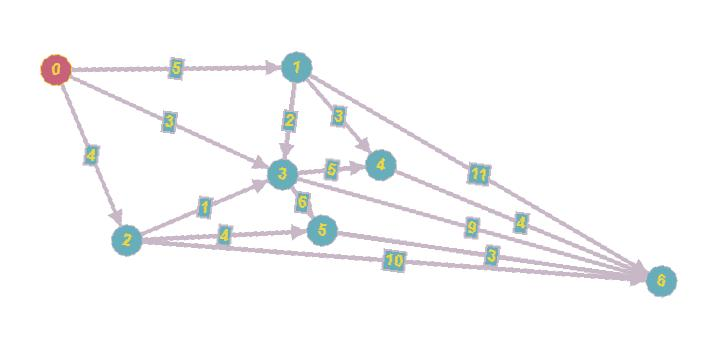

*Consideramos una tabla TARIFAS(i,j) para almacenar todos los precios que nos ofrecen los embarcaderos.<br>
*Si no es posible ir desde i a j daremos un valor alto para garantizar que ese trayecto no se va a elegir en la ruta óptima(modelado habitual para restricciones)

In [179]:
#Viaje por el rio - Programación dinámica
################################################################################

TARIFAS = [
[0,5,4,3,float("inf"),999,999],   #desde nodo 0
[999,0,999,2,3,999,11],  #desde nodo 1
[999,999, 0,1,999,4,10], #desde nodo 2
[999,999,999, 0,5,6,9],
[999,999, 999,999,0,999,4],
[999,999, 999,999,999,0,3],
[999,999,999,999,999,999,0]
]

#999 se puede sustituir por float("inf") del modulo math
TARIFAS

[[0, 5, 4, 3, inf, 999, 999],
 [999, 0, 999, 2, 3, 999, 11],
 [999, 999, 0, 1, 999, 4, 10],
 [999, 999, 999, 0, 5, 6, 9],
 [999, 999, 999, 999, 0, 999, 4],
 [999, 999, 999, 999, 999, 0, 3],
 [999, 999, 999, 999, 999, 999, 0]]

In [180]:
#Calculo de la matriz de PRECIOS y RUTAS
#  PRECIOS - contiene la matriz del mejor precio para ir de un nodo a otro
#  RUTAS   - contiene los nodos intermedios para ir de un nodo a otro
################################################################
def Precios(TARIFAS):
################################################################
  #Total de Nodos
  N = len(TARIFAS[0])

  #Inicialización de la tabla de precios
  PRECIOS = [ [9999]*N for i in [9999]*N]  #n x n
  RUTA = [ [""]*N for i in [""]*N]

  #Se recorren todos los nodos con dos bucles(origen - destino)
  #  para ir construyendo la matriz de PRECIOS
  for i in range(N-1):
    for j in range(i+1, N):
      MIN = TARIFAS[i][j]
      RUTA[i][j] = i

      for k in range(i, j):
        if PRECIOS[i][k] + TARIFAS[k][j] < MIN:
            MIN = min(MIN, PRECIOS[i][k] + TARIFAS[k][j] )
            RUTA[i][j] = k
        PRECIOS[i][j] = MIN

  return PRECIOS,RUTA

In [181]:
PRECIOS,RUTA = Precios(TARIFAS)
#print(PRECIOS[0][6])

print("PRECIOS")
for i in range(len(TARIFAS)):
  print(PRECIOS[i])

print("\nRUTA")
for i in range(len(TARIFAS)):
  print(RUTA[i])

PRECIOS
[9999, 5, 4, 3, 8, 8, 11]
[9999, 9999, 999, 2, 3, 8, 7]
[9999, 9999, 9999, 1, 6, 4, 7]
[9999, 9999, 9999, 9999, 5, 6, 9]
[9999, 9999, 9999, 9999, 9999, 999, 4]
[9999, 9999, 9999, 9999, 9999, 9999, 3]
[9999, 9999, 9999, 9999, 9999, 9999, 9999]

RUTA
['', 0, 0, 0, 1, 2, 5]
['', '', 1, 1, 1, 3, 4]
['', '', '', 2, 3, 2, 5]
['', '', '', '', 3, 3, 3]
['', '', '', '', '', 4, 4]
['', '', '', '', '', '', 5]
['', '', '', '', '', '', '']


In [182]:
#Calculo de la ruta usando la matriz RUTA
def calcular_ruta(RUTA, desde, hasta):
  if desde == RUTA[desde][hasta]:
  #if desde == hasta:
    #print("Ir a :" + str(desde))
    return desde
  else:
    return str(calcular_ruta(RUTA, desde, RUTA[desde][hasta])) +  ',' + str(RUTA[desde][hasta])

print("\nLa ruta es:")
calcular_ruta(RUTA, 0,6)


La ruta es:


'0,2,5'

##Problema de Asignacion de tarea (con medidas de tiempo de ejecución para mejorar nota)

In [183]:
#Asignacion de tareas - Ramificación y Poda
################################################################################
#    T A R E A
#   A
#   G
#   E
#   N
#   T
#   E

COSTES=[[11,12,18,40],
        [14,15,13,22],
        [11,17,19,23],
        [17,14,20,28]]
#Vamos a querer medir tiempos de ejecución para realizar el análisis
import time

In [184]:

#Calculo del valor de una solucion parcial
def valor(S,COSTES):
  VALOR = 0
  for i in range(len(S)):
    VALOR += COSTES[S[i]][i]
  return VALOR
inicio=time.time()
valor((0,1,2,3,  ),COSTES)
fin=time.time()
tiempo=fin-inicio
print(f"El tiempo de ejecución ha sido {tiempo}")
valor((0,1,2,3,  ),COSTES)

El tiempo de ejecución ha sido 0.0001277923583984375


73

In [185]:
#Coste inferior para soluciones parciales
#  (1,3,) Se asigna la tarea 1 al agente 0 y la tarea 3 al agente 1

def CI(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += min( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR

def CS(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += max( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR
inicio=time.time()
CI((0,1),COSTES)
fin=time.time()
tiempo=fin-inicio
print(f"El tiempo de ejecución ha sido {tiempo}")
CI((0,1),COSTES)

El tiempo de ejecución ha sido 0.0001399517059326172


68

In [186]:
#Genera tantos hijos como como posibilidades haya para la siguiente elemento de la tupla
#(0,) -> (0,1), (0,2), (0,3)
def crear_hijos(NODO, N):
  HIJOS = []
  for i in range(N ):
    if i not in NODO:
      HIJOS.append({'s':NODO +(i,)    })
  return HIJOS

In [187]:
inicio=time.time()
crear_hijos((0,) , 4)
fin=time.time()
tiempo=fin-inicio
print(f"El tiempo de ejecución ha sido {tiempo}", crear_hijos((0,) , 4))

El tiempo de ejecución ha sido 0.0002200603485107422 [{'s': (0, 1)}, {'s': (0, 2)}, {'s': (0, 3)}]


In [188]:
def ramificacion_y_poda(COSTES):
#Construccion iterativa de soluciones(arbol). En cada etapa asignamos un agente(ramas).
#Nodos del grafo  { s:(1,2),CI:3,CS:5  }
  #print(COSTES)
  DIMENSION = len(COSTES)
  MEJOR_SOLUCION=tuple( i for i in range(len(COSTES)) )
  CotaSup = valor(MEJOR_SOLUCION,COSTES)
  #print("Cota Superior:", CotaSup)

  NODOS=[]
  NODOS.append({'s':(), 'ci':CI((),COSTES)    } )

  iteracion = 0

  while( len(NODOS) > 0):
    iteracion +=1

    nodo_prometedor = [ min(NODOS, key=lambda x:x['ci']) ][0]['s']
    #print("Nodo prometedor:", nodo_prometedor)

    #Ramificacion
    #Se generan los hijos
    HIJOS =[ {'s':x['s'], 'ci':CI(x['s'], COSTES)   } for x in crear_hijos(nodo_prometedor, DIMENSION) ]

    #Revisamos la cota superior y nos quedamos con la mejor solucion si llegamos a una solucion final
    NODO_FINAL = [x for x in HIJOS if len(x['s']) == DIMENSION  ]
    if len(NODO_FINAL ) >0:
      #print("\n********Soluciones:",  [x for x in HIJOS if len(x['s']) == DIMENSION  ] )
      if NODO_FINAL[0]['ci'] < CotaSup:
        CotaSup = NODO_FINAL[0]['ci']
        MEJOR_SOLUCION = NODO_FINAL

    #Poda
    HIJOS = [x for x in HIJOS if x['ci'] < CotaSup   ]

    #Añadimos los hijos
    NODOS.extend(HIJOS)

    #Eliminamos el nodo ramificado
    NODOS =  [  x for x in NODOS if x['s'] != nodo_prometedor    ]

  print("La solucion final es:" ,MEJOR_SOLUCION , " en " , iteracion , " iteraciones" , " para dimension: " ,DIMENSION  )


inicio=time.time()
ramificacion_y_poda(COSTES)
fin=time.time()
tiempo=fin-inicio
print(f"El tiempo de ejecución ha sido {tiempo}")

La solucion final es: [{'s': (1, 2, 0, 3), 'ci': 64}]  en  10  iteraciones  para dimension:  4
El tiempo de ejecución ha sido 0.0007090568542480469


In [189]:
def fuerza_bruta_recursiva(costes, agente_actual=0, tareas_asignadas=[], coste_acumulado=0):
    global mejor_coste, mejor_solucion

    # Caso base: Todos los agentes tienen una tarea
    if agente_actual == len(costes):
        if coste_acumulado < mejor_coste:
            mejor_coste = coste_acumulado
            mejor_solucion = list(tareas_asignadas)
        return

    # Probar todas las tareas disponibles para el agente actual
    for tarea in range(len(costes)):
        if tarea not in tareas_asignadas:
            # Seleccionamos la tarea y vamos al siguiente agente
            fuerza_bruta_recursiva(
                costes,
                agente_actual + 1,
                tareas_asignadas + [tarea],
                coste_acumulado + costes[agente_actual][tarea]
            )
mejor_coste = float('inf')
mejor_solucion = []
fuerza_bruta_recursiva(COSTES)

In [190]:
import time
print(f"Matriz de costes de 4 dimensiones")
#Vamos a comparar cuanto tiempo tarda en ejecutar este problema por fuerza bruta
#y por ramificación y poda
print("Comparamos tiempos")

# Medidmos el tiemoo de ramificacion_y_poda
print("\nProbamos Ramificacion y Poda...")
inicio = time.time()
ramificacion_y_poda(COSTES)
fin = time.time()
time_ramificacion = fin - inicio # Renamed 'time' to 'time_ramificacion'
print(f"Ramificacion y Poda: {time_ramificacion:.6f} segundos")

# Medimos tiempo para fuerza_bruta_recursiva
print("\nAhora corremos Fuerza Bruta Recursiva...")
global mejor_coste, mejor_solucion
mejor_coste = float('inf')  # Reseteamos variables globales
mejor_solucion = []
inicio_fuerza_bruta = time.time()
fuerza_bruta_recursiva(COSTES)
fin_fuerza_bruta = time.time()
time_fuerza_bruta = fin_fuerza_bruta - inicio_fuerza_bruta
print(f"Fuerza Bruta Recursiva: {time_fuerza_bruta:.6f} segundos")
print(f"Mejor coste (Fuerza Bruta): {mejor_coste}")
print(f"Mejor solucion (Fuerza Bruta): {mejor_solucion}")

print("Comparación")
print(f"Ramificacion y Poda: {time_ramificacion:.6f} segundos")
print(f"Fuerza Bruta Recursiva: {time_fuerza_bruta:.6f} segundos")

Matriz de costes de 4 dimensiones
Comparamos tiempos

Probamos Ramificacion y Poda...
La solucion final es: [{'s': (1, 2, 0, 3), 'ci': 64}]  en  10  iteraciones  para dimension:  4
Ramificacion y Poda: 0.000345 segundos

Ahora corremos Fuerza Bruta Recursiva...
Fuerza Bruta Recursiva: 0.000153 segundos
Mejor coste (Fuerza Bruta): 61
Mejor solucion (Fuerza Bruta): [0, 2, 3, 1]
Comparación
Ramificacion y Poda: 0.000345 segundos
Fuerza Bruta Recursiva: 0.000153 segundos


In [191]:
print(f"Matriz de costes de 5 dimensiones")
COSTES=[[11,12,18,40,6],
        [14,15,13,22,3],
        [14,15,13,22,45],
        [14,15,13,22,56],
        [14,15,13,22,9]
        ]
import time
#Vamos a comparar cuanto tiempo tarda en ejecutar este problema por fuerza bruta
#y por ramificación y poda
print("Comparamos tiempos")

# Medidmos el tiemoo de ramificacion_y_poda
print("\nProbamos Ramificacion y Poda...")
inicio = time.time()
ramificacion_y_poda(COSTES)
fin = time.time()
time_ramificacion = fin - inicio # Renamed 'time' to 'time_ramificacion'
print(f"Ramificacion y Poda: {time_ramificacion:.6f} segundos")

# Medimos tiempo para fuerza_bruta_recursiva
print("\nAhora corremos Fuerza Bruta Recursiva...")
global mejor_coste, mejor_solucion
mejor_coste = float('inf')  # Reseteamos variables globales
mejor_solucion = []
inicio_fuerza_bruta = time.time()
fuerza_bruta_recursiva(COSTES)
fin_fuerza_bruta = time.time()
time_fuerza_bruta = fin_fuerza_bruta - inicio_fuerza_bruta
print(f"Fuerza Bruta Recursiva: {time_fuerza_bruta:.6f} segundos")
print(f"Mejor coste (Fuerza Bruta): {mejor_coste}")
print(f"Mejor solucion (Fuerza Bruta): {mejor_solucion}")

print("Comparación")
print(f"Ramificacion y Poda: {time_ramificacion:.6f} segundos")
print(f"Fuerza Bruta Recursiva: {time_fuerza_bruta:.6f} segundos")

Matriz de costes de 5 dimensiones
Comparamos tiempos

Probamos Ramificacion y Poda...
La solucion final es: [{'s': (0, 4, 2, 1, 3), 'ci': 64}]  en  29  iteraciones  para dimension:  5
Ramificacion y Poda: 0.000569 segundos

Ahora corremos Fuerza Bruta Recursiva...
Fuerza Bruta Recursiva: 0.000916 segundos
Mejor coste (Fuerza Bruta): 64
Mejor solucion (Fuerza Bruta): [0, 4, 1, 2, 3]
Comparación
Ramificacion y Poda: 0.000569 segundos
Fuerza Bruta Recursiva: 0.000916 segundos


Parece que para matrices de costes de hasta 5x5 la fuerza bruta es más rápida, para matrices de dimensiones grandes debería cambiar, vamos a probar con una matriz 8x8

In [192]:
print(f"Matriz de costes de 5 dimensiones")
COSTES=[[11,12,18,40,6,3,2,1],
        [14,15,13,22,3,5,4,3],
        [14,15,13,22,45,6,7,6],
        [14,15,13,22,56,6,7,6],
        [14,15,13,22,9,1,2,3],
        [14,15,13,22,56,1,2,3],
        [14,15,13,22,9,1,2,3],
        [14,15,13,22,9,5,6,5]
        ]
import time
#Vamos a comparar cuanto tiempo tarda en ejecutar este problema por fuerza bruta
#y por ramificación y poda
print("Comparamos tiempos")

# Medidmos el tiemoo de ramificacion_y_poda
print("\nProbamos Ramificacion y Poda...")
inicio = time.time()
ramificacion_y_poda(COSTES)
fin = time.time()
time_ramificacion = fin - inicio # Renamed 'time' to 'time_ramificacion'
print(f"Ramificacion y Poda: {time_ramificacion:.6f} segundos")

# Medimos tiempo para fuerza_bruta_recursiva
print("\nAhora corremos Fuerza Bruta Recursiva...")
global mejor_coste, mejor_solucion
mejor_coste = float('inf')  # Reseteamos variables globales
mejor_solucion = []
inicio_fuerza_bruta = time.time()
fuerza_bruta_recursiva(COSTES)
fin_fuerza_bruta = time.time()
time_fuerza_bruta = fin_fuerza_bruta - inicio_fuerza_bruta
print(f"Fuerza Bruta Recursiva: {time_fuerza_bruta:.6f} segundos")
print(f"Mejor coste (Fuerza Bruta): {mejor_coste}")
print(f"Mejor solucion (Fuerza Bruta): {mejor_solucion}")

print("Comparación")
print(f"Ramificacion y Poda: {time_ramificacion:.6f} segundos")
print(f"Fuerza Bruta Recursiva: {time_fuerza_bruta:.6f} segundos")

Matriz de costes de 5 dimensiones
Comparamos tiempos

Probamos Ramificacion y Poda...
La solucion final es: [{'s': (0, 4, 2, 1, 5, 6, 7, 3), 'ci': 70}]  en  11969  iteraciones  para dimension:  8
Ramificacion y Poda: 2.125345 segundos

Ahora corremos Fuerza Bruta Recursiva...
Fuerza Bruta Recursiva: 0.073419 segundos
Mejor coste (Fuerza Bruta): 70
Mejor solucion (Fuerza Bruta): [0, 4, 1, 2, 5, 6, 7, 3]
Comparación
Ramificacion y Poda: 2.125345 segundos
Fuerza Bruta Recursiva: 0.073419 segundos


Compeljidades:
El método por fuerza bruta tiene n agentes y n iteraciones, hay n! formas de combinarlos;eentonces la complejidad sería de orden $O(n!)$.

Con poda solo sobreviven $b$ hijos por nodo, tras $n$ niveles tenemos $b^n$; $O(b^n)$

Quiero averiguar cuando $b^n<n!$ Esto es encillo, en matemáticas conocemos la aproximación de stirling: https://en.wikipedia.org/wiki/Stirling%27s_approximation
$n!$ lo puedo aproximar (ignorando valores constantes) a $(n/e)^n$.

Entonces $b^n<n!$ se transforma en $b^n<(n/e)^n$; equivalente a $b<(n/e)$;
y finalmente $n>be$. Según chatgpt, $b$ suele estar entre 2 y 4, vamos a tomar b=4 por ser el valor más alto. Entonces $n>10.82$, pero como n debe ser un valor entero, estimo que a partir de $n=11,...$ laa ramificación y poda es más eficiente que la fuerza bruta.

O sea, para dimensiones mayores a 11, ramificación y poda es mejor que fuerza bruta.

##Descenso del gradiente

In [193]:
import math                      #Funciones matematicas
import matplotlib.pyplot as plt  #Generacion de gráficos (otra opcion seaborn)
import numpy as np               #Tratamiento matriz N-dimensionales y otras (fundamental!)
#import scipy as sc

import random

Vamos a buscar el minimo de la funcion paraboloide : $$f(x) =  x² + y²$$

Obviamente se encuentra en (x,y)=(0,0) pero probaremos como llegamos a él a través del descenso del gradiante.

In [194]:
#Definimos la funcion
#Paraboloide
f  = lambda X:      X[0]**2 + X[1]**2    #Funcion
df = lambda X: [2*X[0] , 2*X[1]]         #Gradiente

df([1,2])

[2, 4]

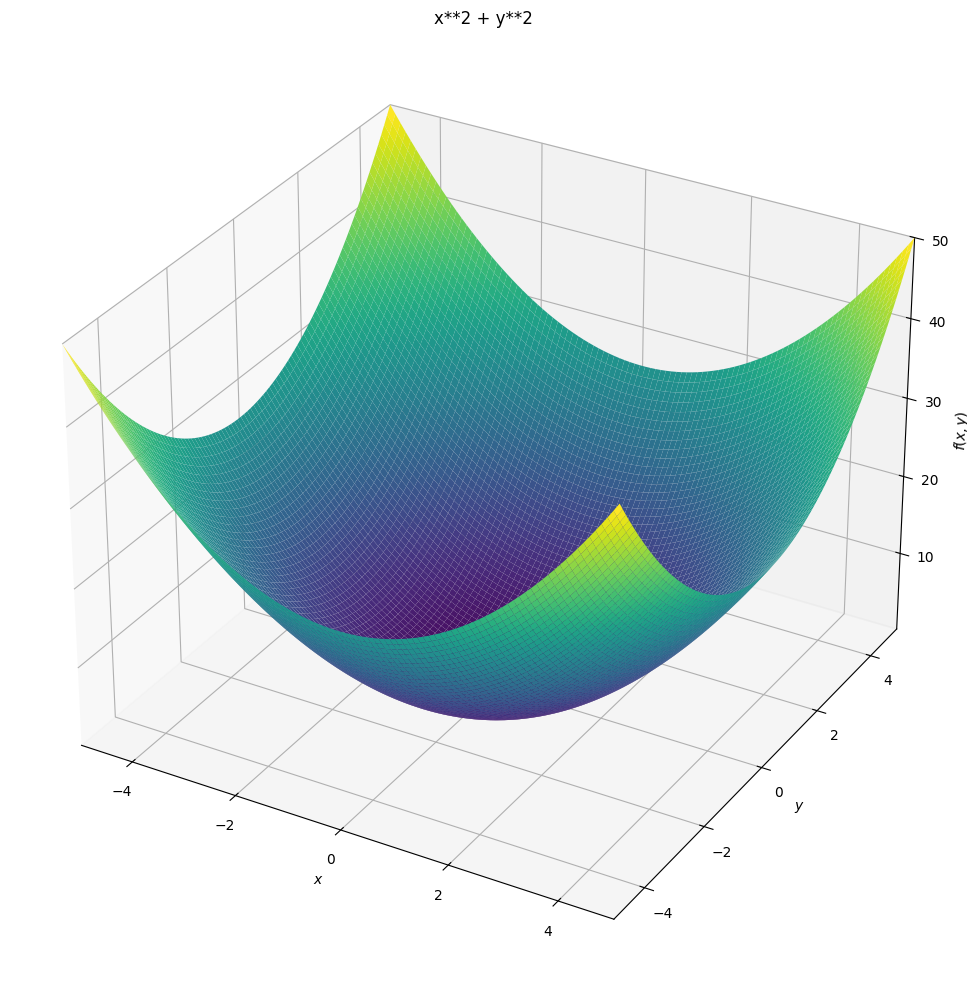

In [195]:
from sympy import symbols
from sympy.plotting import plot
from sympy.plotting import plot3d
x,y = symbols('x y')
plot3d(x**2 + y**2,
       (x,-5,5),(y,-5,5),
       title='x**2 + y**2',
       size=(10,10))

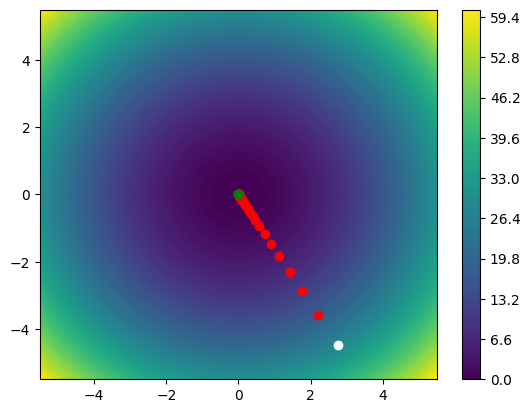

Solucion: [3.943872353535329e-05, -6.392841453142422e-05] 5.642255098599641e-09


In [196]:
#Prepara los datos para dibujar mapa de niveles de Z
resolucion = 100
rango=5.5

X=np.linspace(-rango,rango,resolucion)
Y=np.linspace(-rango,rango,resolucion)
Z=np.zeros((resolucion,resolucion))
for ix,x in enumerate(X):
  for iy,y in enumerate(Y):
    Z[iy,ix] = f([x,y])

#Pinta el mapa de niveles de Z
plt.contourf(X,Y,Z,resolucion)
plt.colorbar()

#Generamos un punto aleatorio inicial y pintamos de blanco
P=[random.uniform(-5,5  ),random.uniform(-5,5 ) ]
plt.plot(P[0],P[1],"o",c="white")

#Tasa de aprendizaje. Fija. Sería más efectivo reducirlo a medida que nos acercamos.
TA=.1

#Iteraciones:50
for _ in range(50):
  grad = df(P)
  #print(P,grad)
  P[0],P[1] = P[0] - TA*grad[0] , P[1] - TA*grad[1]
  plt.plot(P[0],P[1],"o",c="red")

#Dibujamos el punto final y pintamos de verde
plt.plot(P[0],P[1],"o",c="green")
plt.show()
print("Solucion:" , P , f(P))


**¿Te atreves a optimizar la función?:**

$$f(x)=sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - e^y)$$
<br>
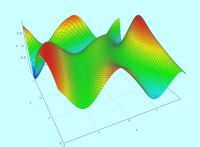


$$f(x)=sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - e^y)$$,
derivadas parciales:


*   $\frac{\partial f}{\partial x}=x cos(1 - e^y + 2 x) cos(3 + x^2/2 - y^2/4) - 2 sin(1 - e^y + 2 x) sin(3 + x^2/2 - y^2/4)$
*   $\frac{\partial f}{\partial y}=-1/2 y cos(1 - e^y + 2 x) cos(3 + x^2/2 - y^2/4) + e^y sin(1 - e^y + 2 x) sin(3 + x^2/2 - y^2/4)$

Y entonces el gradiente: $\nabla f=(\frac{\partial f}{\partial x},\frac{\partial f}{\partial y})=(x cos(1 - e^y + 2 x) cos(3 + x^2/2 - y^2/4) - 2 sin(1 - e^y + 2 x) sin(3 + x^2/2 - y^2/4),-1/2 y cos(1 - e^y + 2 x) cos(3 + x^2/2 - y^2/4) + e^y sin(1 - e^y + 2 x) sin(3 + x^2/2 - y^2/4))$

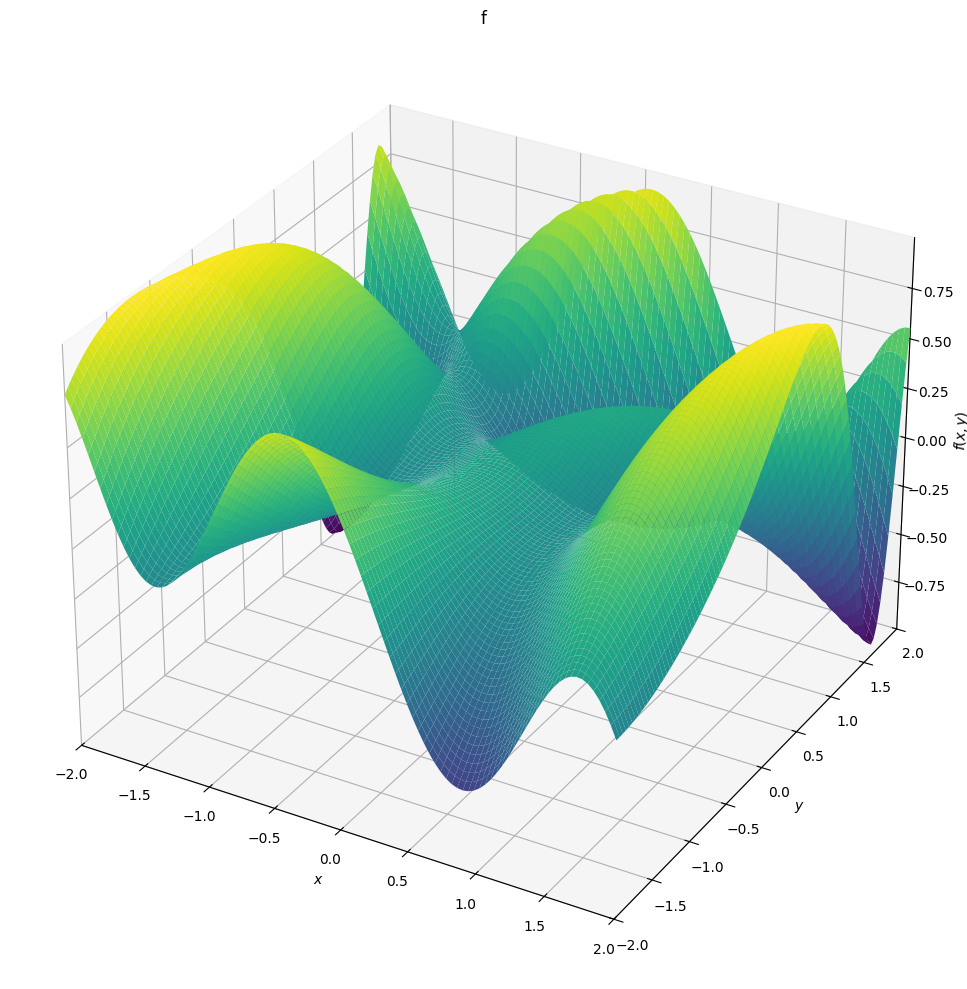

In [200]:
from sympy import symbols, sin, cos, exp
from sympy.plotting import plot
from sympy.plotting import plot3d
#Definimos la funcion
f= lambda X: math.sin(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) *math.cos(2*X[0] + 1 - math.exp(X[1]))
df = lambda X: [

    X[0] * math.cos(1 - math.exp(X[1]) + 2*X[0]) * math.cos(3 + X[0]**2/2 - X[1]**2/4) -
    2 * math.sin(1 - math.exp(X[1]) + 2*X[0]) * math.sin(3 + X[0]**2/2 - X[1]**2/4),

    -0.5 * X[1] * math.cos(1 - math.exp(X[1]) + 2*X[0]) * math.cos(3 + X[0]**2/2 - X[1]**2/4) +
    math.exp(X[1]) * math.sin(1 - math.exp(X[1]) + 2*X[0]) * math.sin(3 + X[0]**2/2 - X[1]**2/4)
]

x, y = symbols('x y')
plot3d(sin(0.5 * x**2 - 0.25 * y**2 + 3) * cos(2*x + 1 - exp(y)),
       (x, -2, 2), (y, -2, 2),
       title='f',
       size=(10, 10))


La presencia de múltiples extremos locales delata que la función dada es no convexa.

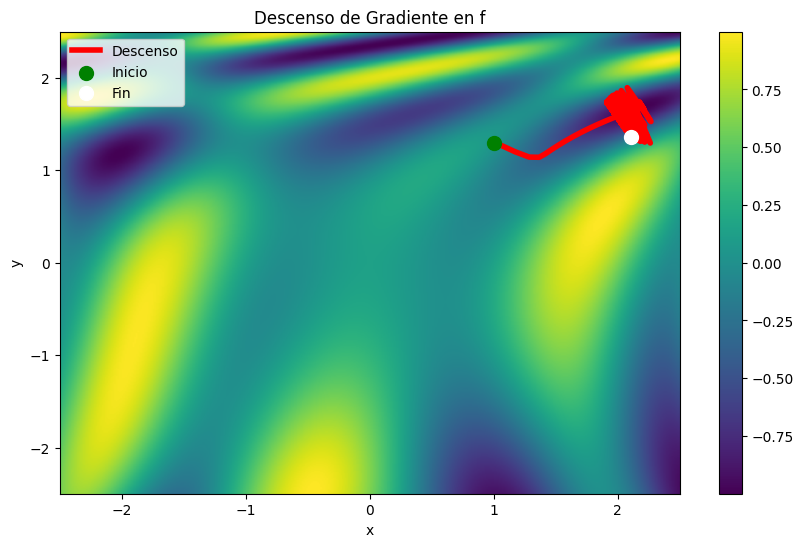

Solucion: [x=2.1073543736926634, y=1.3588731300688908] f=-0.24509714013314848335
Tiempo de ejecución: 0.5572185516357422


In [211]:
import numpy as np
import matplotlib.pyplot as plt
import time

inicio=time.time()
# Definición de la función
def f(x, y):
    return np.sin(0.5 * x**2 - 0.25 * y**2 + 3) * np.cos(2*x + 1 - np.exp(y))

# Gradiente aproximado (usando diferencias finitas para mayor facilidad)
def gradient(x, y, h=1e-5):
    df_dx = (f(x + h, y) - f(x - h, y)) / (2 * h)
    df_dy = (f(x, y + h) - f(x, y - h)) / (2 * h)
    return np.array([df_dx, df_dy])
# Parámetros del algoritmo
punto_inicial = np.array([1, 1.3]) # Podemos cambiarlo para caer en otros mínimos
learning_rate = 0.1
iteraciones = 100

trayectoria = [punto_inicial]
punto_actual = punto_inicial

for _ in range(iteraciones):
    grad = gradient(punto_actual[0], punto_actual[1])
    punto_actual = punto_actual - learning_rate * grad
    trayectoria.append(punto_actual)

trayectoria = np.array(trayectoria)
# Crear el fondo
x = np.linspace(-2.5, 2.5, 400)
y = np.linspace(-2.5, 2.5, 400)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

plt.figure(figsize=(10, 6))
# Dibujar el mapa de calor
plt.imshow(Z, extent=[-2.5, 2.5, -2.5, 2.5], origin='lower', cmap='viridis', aspect='auto')
plt.colorbar()

# Dibujar la trayectoria del gradiente
plt.plot(trayectoria[:, 0], trayectoria[:, 1], color='red', linewidth=4, label='Descenso')
plt.scatter(trayectoria[0, 0], trayectoria[0, 1], color='green', s=100, label='Inicio', zorder=5)
plt.scatter(trayectoria[-1, 0], trayectoria[-1, 1], color='white', s=100, label='Fin', zorder=5)

plt.title("Descenso de Gradiente en f")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()
# Extraer el último punto y su valor
minimo_x, minimo_y = trayectoria[-1]
valor_minimo = f(minimo_x, minimo_y)
print(f"Solucion: [x={minimo_x:.16f}, y={minimo_y:.16f}] f={valor_minimo:.20f}")
fin=time.time()
print(f"Tiempo de ejecución: {fin-inicio}")

Parece que el mínimo obtenido varía enormemente según el punto de inicioç
¿Habrá alguna forma de hacerlo global?
lo único que se me ocurre es trabajar con muchos puntos iniciales:

In [212]:
import numpy as np

puntos_inicio = [np.array([1, 1]), np.array([-1, -2]), np.array([2, 0]), np.array([-2, 1])]
mejor_solucion = None
mejor_valor = float('inf')

for p in puntos_inicio:
    resultado_local = punto_actual  # punto final tras el bucle
    valor_local = f(resultado_local[0], resultado_local[1])

    if valor_local < mejor_valor:
        mejor_valor = valor_local
        mejor_solucion = resultado_local

print(f"Mínimo Global encontrado: {mejor_solucion} con valor {mejor_valor}")

Mínimo Global encontrado: [2.10735437 1.35887313] con valor -0.24509714013314848


# Referencias


*   https://en.wikipedia.org/wiki/Stirling%27s_approximation Aproximación de Stirling
* He usado chatgpt para averiguar el valor de b en ramificación y poda, parece un valor que suele estar entre 2 y 4.
*   Se uso chatgpt para el plot del mapa de calor

